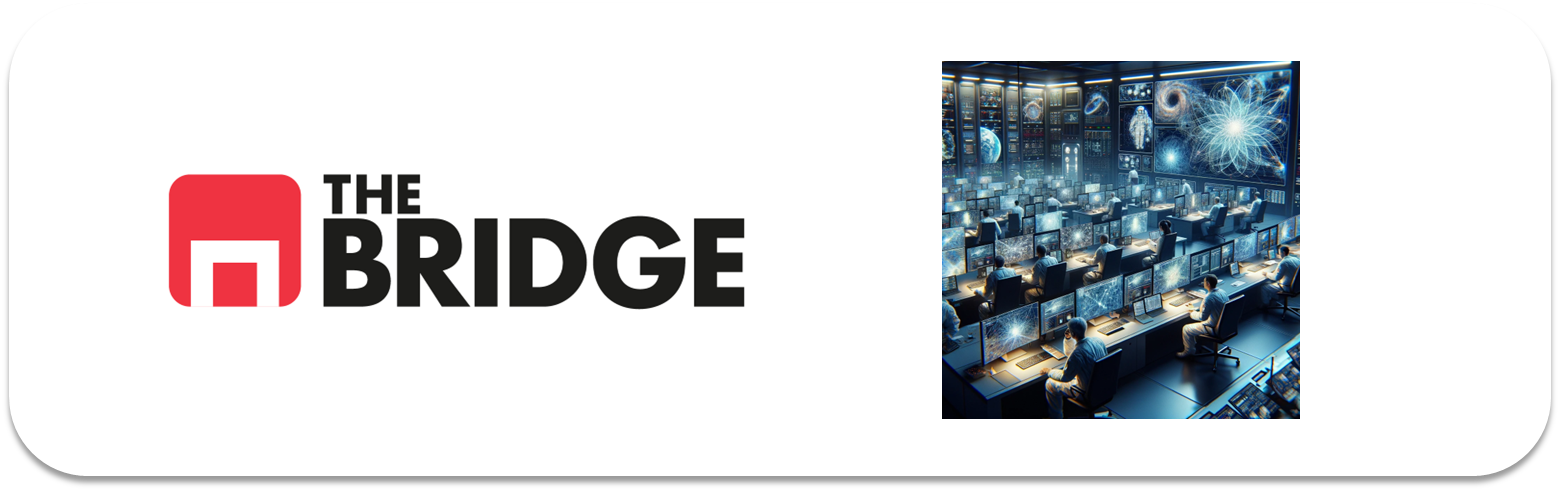

## PRACTICA OBLIGATORIA: **Redes Convolucionales**

* La práctica obligatoria de esta unidad consiste en un ejercicio de construcción de una red convolucional con Keras para la clasificación de imagenes de simpáticos perretes y gatetes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import bootcampviztools as bt
import cv2
import matplotlib.pyplot as plt
import numpy as np 
import os
import pandas as pd 
import seaborn as sns

from keras.models import Sequential
from keras.layers import Conv2D
from keras.layers import MaxPool2D 
from keras.layers import Dropout
from keras.layers import Flatten, Dense
from keras.optimizers import Adam
import tensorflow as tf
from tensorflow import keras

from sklearn.preprocessing import LabelEncoder 
from sklearn.utils import shuffle
from sklearn.metrics import classification_report, ConfusionMatrixDisplay



import warnings
# filter warnings
warnings.filterwarnings('ignore')

### Problema de Negocio y dataset

Una conocida empresa de información inmobiliaria utiliza un CAPTCHA visual de perros y gatos para detectar webscrappings intensivos y ataques de denegación de servicio. Últimamente, ha detectado que su sistema está empezando a flojear, es decir que hay muchos sistemas de detección automática de imágenes que son capaces de detectar que es un perro y un gato y salterse el CAPTCHA antirobots. Por eso nos ha pedido que entrenemos un modelo potente de clasificación que emule a estos sistemas con el objetivo de emplear como fotografías para el CAPTCHA aquellas que no sepa detectar este sistema emulador de chicos malos.  

Pues manos a la obra, tenemos que seleccionar en un conjunto de 1000 imágenes aquellas que peor se le daría clasificar a un potencial sistema anti-CAPTCHA.  

Para ello vamos a emplear un conjunto de train de 4000 imágenes de perretes y gatetes que se encuentran distribuidas en "data" en cuatro directorios "github_train_0",  "github_train_1", "githun_train_2" y "github_train_3". Los datos de las imagenes que tenemos que clasificar y luego seleccionar como las más "difíciles" están en "data" en el directorio "github_test".


### Se pide

1. Crear los datasets X,y de train y test, leyendo las imágenes de los directorios correspondientes (tendrás que leer todas las imágenes de los cuatro directorios para train) y a la vez que se leen adaptar su resolución para que todas tengan un tamaño de 32x32. En este caso puedes adaptar las funciones de los ejercicios de la unidad. NOTA: Ten en cuenta que la clase a la que pertenece en la foto está en el nombre del archivo.

2. Crea un modelo DL basado en redes convolucionales con al menos dos juegos Convolucional-Pooling. Sigue todo el proceso de ML (visualización del dataset, MiniEDA, Construcción del modelo)

3. Entrenar el modelo con un callback de Earlystopping con paciencia la que tengas :-). Muestra su historial de entrenamiento.

4. Evalua el modelo, haz un reporte de clasificacion y muestra la matriz de confianza.

5. Es el momento de seleccionar las imagenes: Selecciona el 10% de imágenes mal clasificadas de una y otra clase que tengan el mayor nivel de confianza de que pertenencían a la clase errónea. Es decir las imágenes de perros clasificadas como gatos y con la probabilidad de ser perro más alta.






In [2]:
def read_data(directorio, reshape_dim=(32, 32)):
    X = []
    y = []
    for file in os.listdir(directorio):
        file_path = os.path.join(directorio, file)
        if os.path.isfile(file_path):  # Filtra solo archivos, ignora subcarpetas
            image = cv2.imread(file_path)
            image = cv2.resize(image, reshape_dim)
            X.append(image)
            y.append(os.path.splitext(file)[0].rstrip("0123456789."))
    return np.array(X), np.array(y)

In [3]:
directorios = [
    "./data/github_train_0",
    "./data/github_train_1",
    "./data/github_train_2",
    "./data/github_train_3"
]

X_list, y_list = [], []
for directorio in directorios:
    X_i, y_i = read_data(directorio)
    X_list.append(X_i)
    y_list.append(y_i)

X_train = np.concatenate(X_list)
y_train = np.concatenate(y_list)

In [4]:
print(X_train.shape)
print(y_train.shape)
print("Etiquetas: ", np.unique(y_train))

(4000, 32, 32, 3)
(4000,)
Etiquetas:  ['cat' 'dog']


In [5]:
def plot_digits(digits,  labels = [],
                n_cols = 5,):
    '''
    Función para visualizar las imágenes
    '''
    n_rows = ((len(digits) - 1) // n_cols + 1) # división entera 
                                               # devuelve solo la parte entera del cociente
                                               # por ejemplo 5 // 2 = 2  
    plt.figure(figsize=(n_cols * 2, n_rows * 2.2))
    if isinstance(digits,pd.DataFrame):
        digits_val = digits.values.reshape(-1,28,28)
    else:
        digits_val = digits
    for index, digit in enumerate(digits_val):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(digit) # El parámetro cmap en plt.imshow() se ignora automáticamente cuando la imagen tiene 3 canales RGB — matplotlib simplemente la muestra en color.
        plt.axis("off")
        if len(labels):
            if isinstance(labels, pd.Series):
                plt.title(labels.iloc[index])
            else:
                plt.title(labels[index])

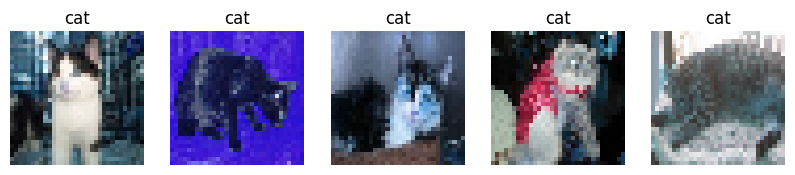

In [6]:
plot_digits(X_train[0:5],
            y_train[0:5])

Que imágenes tan malas.

In [7]:
# Genero test y veo que medidas tiene
X_test, y_test = read_data("./data/github_test")
print(X_test.shape)
print(y_test.shape)
print("Etiquetas: ", np.unique(y_test))


(1000, 32, 32, 3)
(1000,)
Etiquetas:  ['cat' 'dog']


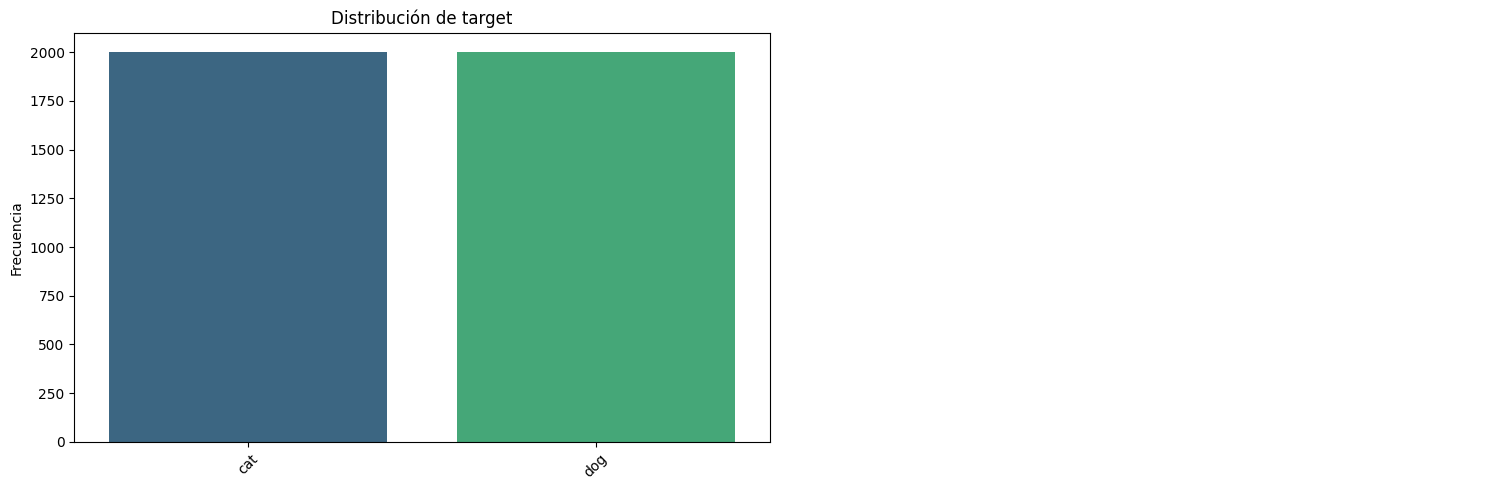

In [8]:
# import bootcampviztools as bt
df = pd.DataFrame({"target": y_train})
bt.pinta_distribucion_categoricas(df, ["target"])

El target está completamente equilibrado, tiene 50% de cada categoría.

In [9]:
# Comprobar los valores máximo y mínimo de los pixeles.
print(X_train.min())   
print(X_train.max())

0
255


In [10]:
# Escalamos tanto train como test
X_train = X_train/255
X_test = X_test/255
# ¡OJO! No escalamos el target.
print(X_train.min())   
print(X_train.max())

0.0
1.0


In [11]:
print(X_train[0])

[[[0.25098039 0.39215686 0.49411765]
  [0.20784314 0.36078431 0.4627451 ]
  [0.24705882 0.40784314 0.50588235]
  ...
  [0.17647059 0.27058824 0.34509804]
  [0.09803922 0.15686275 0.38431373]
  [0.19607843 0.28235294 0.4745098 ]]

 [[0.23921569 0.36078431 0.44313725]
  [0.26666667 0.4        0.47843137]
  [0.29411765 0.43529412 0.51372549]
  ...
  [0.22352941 0.29411765 0.51372549]
  [0.09019608 0.20784314 0.38823529]
  [0.08627451 0.16470588 0.38823529]]

 [[0.25098039 0.37647059 0.47058824]
  [0.29019608 0.43137255 0.52156863]
  [0.24705882 0.40392157 0.49411765]
  ...
  [0.04705882 0.09803922 0.30980392]
  [0.00784314 0.04705882 0.19607843]
  [0.02352941 0.1254902  0.30980392]]

 ...

 [[0.03921569 0.05882353 0.05882353]
  [0.27058824 0.30980392 0.32156863]
  [0.2        0.2627451  0.28627451]
  ...
  [0.27058824 0.37254902 0.40392157]
  [0.20784314 0.29411765 0.3254902 ]
  [0.23529412 0.36078431 0.38431373]]

 [[0.34509804 0.38823529 0.38039216]
  [0.19215686 0.24705882 0.25882353]


In [12]:
32*32*3

3072

In [13]:
# Convertir las etiquetas a enteros
# from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

print("Etiquetas: ", np.unique(y_train))

Etiquetas:  [0 1]


In [14]:
# Anular los warnings de Sequential
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
# Contruir el modelo
# Instanciamos
model = Sequential()
#Capas
model.add(Conv2D(filters = 8, kernel_size = (5,5),padding = 'Same', 
                 activation ='relu', input_shape = (32,32,3)))
model.add(Conv2D(filters = 8, kernel_size = (5,5),padding = 'Same', 
                 activation ='relu'))
model.add(MaxPool2D(pool_size=(2,2), strides = (2,2)))
model.add(Dropout(rate= 0.25))

model.add(Conv2D(filters = 16, kernel_size = (3,3),padding = 'Same', 
                 activation ='relu'))
model.add(Conv2D(filters = 16, kernel_size = (3,3),padding = 'Same', 
                 activation ='relu'))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))
model.add(Dropout(0.25))

# Cabeza
print("Entrada de la capa flatten:", model.output_shape)
model.add(Flatten()) 
print("Salida de la capa flatten:",model.output_shape)
model.add(Dense(32, activation = "relu")) # Buscar una cantidad acorde al tamaño de los datos.
model.add(Dropout(0.5))
model.add(Dense(1, activation = "sigmoid"))



Entrada de la capa flatten: (None, 8, 8, 16)
Salida de la capa flatten: (None, 1024)


sigmoid → porque comprime cualquier valor al rango [0, 1], interpretándolo como una probabilidad. Por ejemplo:  
salida 0.8 → 80% de probabilidad de ser dog  
salida 0.2 → 20% de probabilidad de ser dog → es cat  

In [15]:
optimizer = Adam(learning_rate =0.001, beta_1=0.9, beta_2=0.999)
model.compile(optimizer = optimizer ,
               loss = "binary_crossentropy",
                 metrics=["accuracy"])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 8)      │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 8)      │         1,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        32,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,537 (150.54 KB)

 Trainable params: 38,537 (150.54 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
early_stop = keras.callbacks.EarlyStopping(
    patience=10,
    restore_best_weights=True)

history = model.fit(X_train, y_train, batch_size = 128, 
                    epochs= 500,
                     validation_split= 0.2,
                     callbacks=[early_stop])

Epoch 1/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.6178 - loss: 0.6697 - val_accuracy: 0.0000e+00 - val_loss: 0.8735
Epoch 2/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6250 - loss: 0.6666 - val_accuracy: 0.0000e+00 - val_loss: 0.8654
Epoch 3/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6247 - loss: 0.6588 - val_accuracy: 0.0025 - val_loss: 0.7995
Epoch 4/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6250 - loss: 0.6577 - val_accuracy: 0.0000e+00 - val_loss: 0.7857
Epoch 5/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6209 - loss: 0.6449 - val_accuracy: 0.4800 - val_loss: 0.7252
Epoch 6/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6334 - loss: 0.6338 - val_accuracy: 0.1037 - val_loss: 0.8675
Epoch 7/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6531 - loss: 0.6227 - val_accuracy: 0.4563 - val_loss: 0.7671
Epoch 8/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6672 - loss: 0.6129 - val_

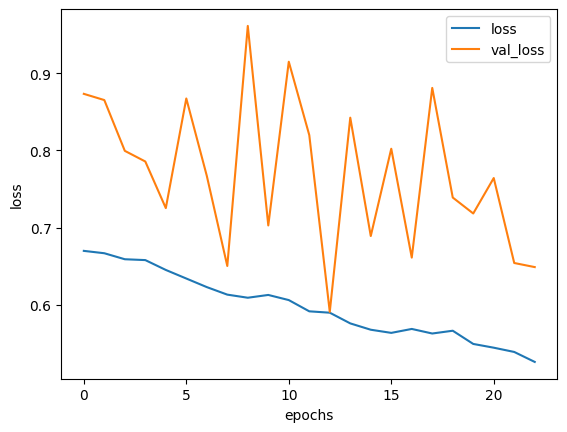

In [17]:
# Visualizamos la función de perdida y las métricas
history_df = pd.DataFrame(history.history)
history_df[["loss","val_loss"]].plot();
plt.xlabel("epochs")
plt.ylabel("loss");

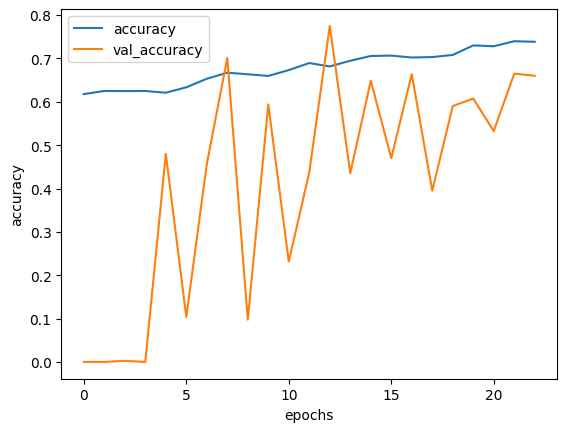

In [18]:
history_df = pd.DataFrame(history.history)
history_df[["accuracy","val_accuracy"]].plot();
plt.xlabel("epochs")
plt.ylabel("accuracy");

In [19]:
print(history_df)

    accuracy      loss  val_accuracy  val_loss
0   0.617813  0.669688       0.00000  0.873493
1   0.625000  0.666615       0.00000  0.865430
2   0.624687  0.658823       0.00250  0.799513
3   0.625000  0.657722       0.00000  0.785681
4   0.620938  0.644933       0.48000  0.725214
5   0.633438  0.633795       0.10375  0.867492
6   0.653125  0.622666       0.45625  0.767081
7   0.667188  0.612890       0.70125  0.650090
8   0.663437  0.608863       0.09750  0.961665
9   0.659688  0.612481       0.59375  0.702699
10  0.673125  0.605819       0.23125  0.915191
11  0.689375  0.591221       0.43750  0.819918
12  0.681562  0.589446       0.77500  0.590499
13  0.694687  0.575553       0.43500  0.842561
14  0.705625  0.567334       0.64875  0.688951
15  0.706563  0.563245       0.47000  0.802253
16  0.702187  0.568353       0.66375  0.660971
17  0.703125  0.562427       0.39500  0.881181
18  0.708125  0.566037       0.59000  0.738923
19  0.730000  0.548888       0.60750  0.718221
20  0.728125 

Los datos estaban ordenados, por lo tanto la validación posiblemente ha cogido los últimos datos que eran todos dog. Por eso la validación tiene esos saltos.

In [20]:
# Barajamos los datos para que se mezclen cat y dog
# from sklearn.utils import shuffle

X_train_bar, y_train_bar = shuffle(X_train, y_train, random_state=42)

In [21]:
# Volvemos a entrenar
model_bar = Sequential()
#Capas
model_bar.add(Conv2D(filters = 8, kernel_size = (5,5),padding = 'Same', 
                 activation ='relu', input_shape = (32,32,3)))
model_bar.add(Conv2D(filters = 8, kernel_size = (5,5),padding = 'Same', 
                 activation ='relu'))
model_bar.add(MaxPool2D(pool_size=(2,2), strides = (2,2)))
model_bar.add(Dropout(rate= 0.25))

model_bar.add(Conv2D(filters = 16, kernel_size = (3,3),padding = 'Same', 
                 activation ='relu'))
model_bar.add(Conv2D(filters = 16, kernel_size = (3,3),padding = 'Same', 
                 activation ='relu'))
model_bar.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))
model_bar.add(Dropout(0.25))

# Cabeza
print("Entrada de la capa flatten:", model_bar.output_shape)
model_bar.add(Flatten()) 
print("Salida de la capa flatten:",model_bar.output_shape)
model_bar.add(Dense(32, activation = "relu")) # Buscar una cantidad acorde al tamaño de los datos.
model_bar.add(Dropout(0.5))
model_bar.add(Dense(1, activation = "sigmoid"))


Entrada de la capa flatten: (None, 8, 8, 16)
Salida de la capa flatten: (None, 1024)


In [22]:
optimizer = Adam(learning_rate =0.001, beta_1=0.9, beta_2=0.999)
model_bar.compile(optimizer = optimizer ,
               loss = "binary_crossentropy",
                 metrics=["accuracy"])

model_bar.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 8)      │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 8)      │         1,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │        32,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,537 (150.54 KB)

 Trainable params: 38,537 (150.54 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
early_stop = keras.callbacks.EarlyStopping(
    patience=10,
    restore_best_weights=True)

history_bar = model_bar.fit(X_train_bar, y_train_bar, batch_size = 128, 
                    epochs= 500,
                     validation_split= 0.2,
                     callbacks=[early_stop])

Epoch 1/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5006 - loss: 0.6938 - val_accuracy: 0.5200 - val_loss: 0.6905
Epoch 2/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5300 - loss: 0.6907 - val_accuracy: 0.5725 - val_loss: 0.6897
Epoch 3/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5628 - loss: 0.6828 - val_accuracy: 0.5487 - val_loss: 0.6786
Epoch 4/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5984 - loss: 0.6710 - val_accuracy: 0.5475 - val_loss: 0.6928
Epoch 5/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6147 - loss: 0.6626 - val_accuracy: 0.6475 - val_loss: 0.6467
Epoch 6/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6169 - loss: 0.6473 - val_accuracy: 0.6350 - val_loss: 0.6401
Epoch 7/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6534 - loss: 0.6250 - val_accuracy: 0.6200 - val_loss: 0.6409
Epoch 8/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6513 - loss: 0.6277 - val_accuracy: 0.

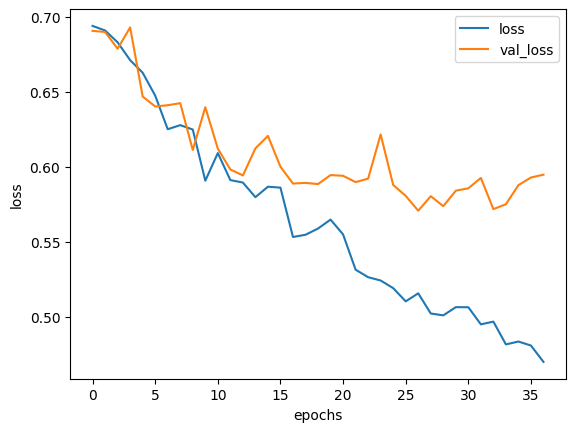

In [24]:
# Visualizamos la función de perdida y las métricas
history_df_bar = pd.DataFrame(history_bar.history)
history_df_bar[["loss","val_loss"]].plot();
plt.xlabel("epochs")
plt.ylabel("loss");

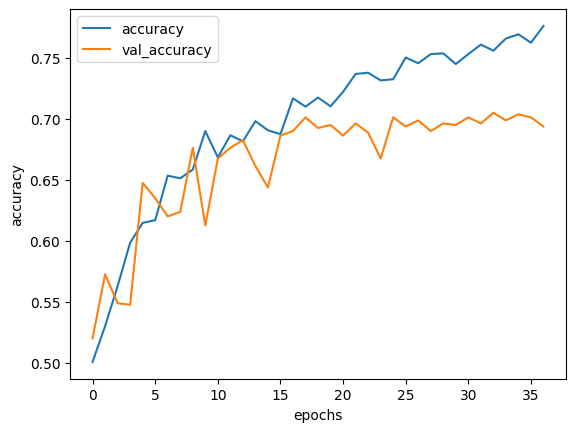

In [25]:
history_df_bar[["accuracy","val_accuracy"]].plot();
plt.xlabel("epochs")
plt.ylabel("accuracy");

In [26]:
print(history_df_bar)

    accuracy      loss  val_accuracy  val_loss
0   0.500625  0.693754       0.52000  0.690460
1   0.530000  0.690718       0.57250  0.689728
2   0.562813  0.682819       0.54875  0.678563
3   0.598437  0.670958       0.54750  0.692764
4   0.614688  0.662580       0.64750  0.646735
5   0.616875  0.647330       0.63500  0.640123
6   0.653437  0.624958       0.62000  0.640931
7   0.651250  0.627670       0.62375  0.642310
8   0.658437  0.624749       0.67625  0.611119
9   0.690000  0.590679       0.61250  0.639629
10  0.668437  0.609068       0.66750  0.612040
11  0.686562  0.591080       0.67625  0.598134
12  0.681562  0.589439       0.68250  0.594184
13  0.698125  0.579703       0.66125  0.612190
14  0.690625  0.586668       0.64375  0.620497
15  0.687500  0.586039       0.68625  0.599976
16  0.716875  0.553185       0.69000  0.588776
17  0.710000  0.554666       0.70125  0.589224
18  0.717500  0.558813       0.69250  0.588421
19  0.710312  0.564768       0.69500  0.594411
20  0.722188 

In [27]:
test_loss, test_acc = model_bar.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7130 - loss: 0.5755
Test accuracy: 0.7130
Test loss: 0.5755


In [28]:
# y_pred =  model_bar.predict(X_test)
# print(classification_report(y_test,y_pred))
# Da error probablemente porque el modelo devuelve probabilidades, no clases.
# Hace falta convertirlas primero:
y_pred = (model.predict(X_test) > 0.5).astype(int)
# El > 0.5 convierte la salida sigmoid en 0 o 1 (lo que es mayor de 0.5 =1)
print(classification_report(y_test, y_pred, target_names=["cat", "dog"]))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
              precision    recall  f1-score   support

         cat       0.74      0.58      0.65       500
         dog       0.65      0.80      0.72       500

    accuracy                           0.69      1000
   macro avg       0.70      0.69      0.68      1000
weighted avg       0.70      0.69      0.68      1000



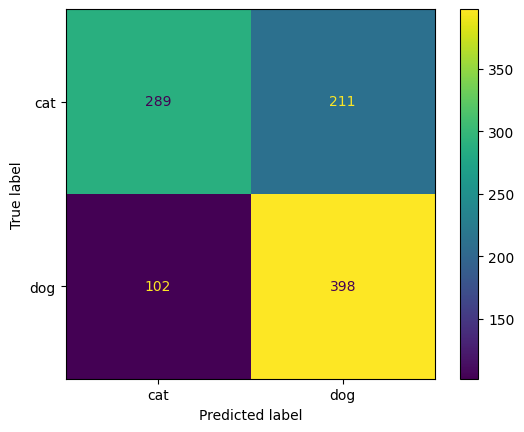

In [29]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred,display_labels=["cat", "dog"])

In [40]:
y_prob = model_bar.predict(X_test).squeeze()  # Hay que aplanarlo para que tenga forma (1000,)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [41]:
y_pred = (y_prob > 0.35).astype(int)
print(classification_report(y_test, y_pred, target_names=["cat", "dog"]))

              precision    recall  f1-score   support

         cat       0.79      0.45      0.57       500
         dog       0.61      0.88      0.72       500

    accuracy                           0.66      1000
   macro avg       0.70      0.66      0.65      1000
weighted avg       0.70      0.66      0.65      1000



5. Es el momento de seleccionar las imagenes: Selecciona el 10% de imágenes mal clasificadas de una y otra clase que tengan el mayor nivel de confianza de que pertenecían a la clase errónea. Es decir las imágenes de perros clasificadas como gatos y con la probabilidad de ser perro más alta.

In [ ]:
# Identificar los mal clasificados
incorrectos_mask = (y_pred != y_test)  # --> Lo tengo claro
# Nos devuelve True/False para las 1000 etiquetas
print(incorrectos_mask.sum()) 
# Me quedo solo con los incorrectos <-- Esta variable es la importante
indices_incorrectos = np.where(incorrectos_mask)[0]  # solo los índices donde es True
print(indices_incorrectos.shape)   

print(y_test.shape)
print(incorrectos_mask.shape)
print(len(incorrectos_mask),type(incorrectos_mask))
print(y_prob.shape, type(y_prob))
print(y_prob[0])



337
(337,)
(1000,)
(1000,)
1000 <class 'numpy.ndarray'>
(1000,) <class 'numpy.ndarray'>
0.5362591


### Extra (para hacer en clase)

Repite los pasos 3 a 5 utilizando el generador de imágenes sintéticas o Image Augmentation de Keras. 